# The Lotka-Volterra model
This model is a python translation of the LV_pz model proposed in Glover et al. (2011), Sec. 9.3

You will need to make sure the required modules below are installed in your python environment

In [5]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

This is the function containing the right hand side of the ODE system

In [6]:
def LV_pz(x,t,p):
    X1,X2 = x
    p1,p2,p3,p4 = p
    dX1dt = X1 * (p1 - p2*X2)
    dX2dt = X2 * (p3*p2*X1 - p4)
    return np.array([dX1dt,dX2dt])

## Parameters and initial conditions

In [7]:
# The parameters
p = np.array([0.1,0.4,0.2,0.05])
X1_0 = 0.8
X2_0 = 0.171
x0 = np.array([X1_0,X2_0])

## Time axis

In [8]:
# time units are days
Tstart = 0.
Tend = 400.
step = 0.1
t = np.arange(Tstart,Tend,step)

## Integration using the scipy ODE solver

In [9]:
# note that the extra argument containing the parameter "args" must be a tuple
y = odeint(LV_pz, x0, t, args=(p,))

## Plot Fig. 9.3a

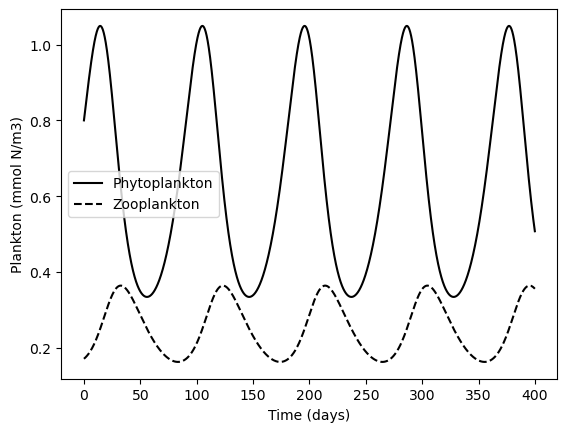

In [10]:
plt.plot(t,y[:,0],'k-',label='Phytoplankton')
plt.plot(t,y[:,1],'k--',label='Zooplankton')
plt.xlabel('Time (days)')
plt.ylabel('Plankton (mmol N/m3)')
plt.legend()
plt.show()

# Exercise 3
1. Write the code to plot Fig. 9.3b, the trajectory in the phase space

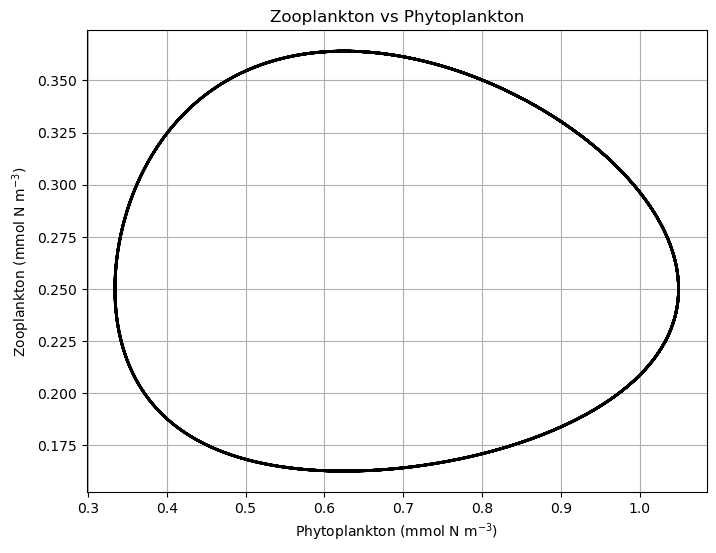

In [13]:
plt.figure(figsize=(8,6))

plt.plot(y[:,0], y[:,1], 'k-', linewidth=2)

plt.xlabel('Phytoplankton (mmol N m$^{-3}$)')
plt.ylabel('Zooplankton (mmol N m$^{-3}$)')
plt.title('Zooplankton vs Phytoplankton')
plt.grid(True)

plt.show()

2. Set the parameter p3=1 and compare how different the trajectory is in the phase space

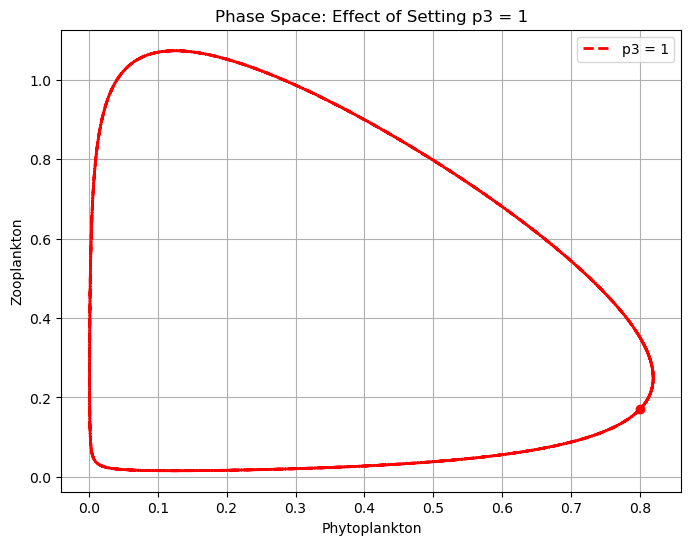

In [23]:
# Original parameter set


# Modified parameter set with p3 = 1
p_mod = p.copy()
p_mod[2] = 1.0    # p3 is the third parameter

y_mod  = odeint(LV_pz, x0, t, args=(p_mod,))

# Compare phase-space trajectories
plt.figure(figsize=(8,6))



plt.plot(y_mod[:,0], y_mod[:,1],
         'r--', linewidth=2,
         label='p3 = 1')

# Mark start points

plt.plot(y_mod[0,0], y_mod[0,1], 'ro')

plt.xlabel('Phytoplankton')
plt.ylabel('Zooplankton')
plt.title('Phase Space: Effect of Setting p3 = 1')
plt.legend()
plt.grid(True)

plt.show()


3. Write the code to compute the solution of the L-V model using the initial conditions given in the caption of Fig. 9.4

4. Do you get the same results? Why not? See the errata in the document Glover_etal_2011_ERRATA.pdf to understand more {no need to fully understand the stability analysis ;)}